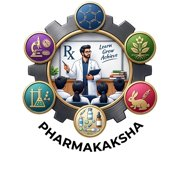

# BP301T · Unit IV — Tree-Based Models and Ensemble Learning
**Pharmakaksha · Learn · Grow · Achieve**
*Introduction to Machine Learning in Pharmaceutical Sciences · B.Pharm Semester III · PCI NEP 2020*

This notebook contains every example and demo from the Unit IV study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit4_Tree_Models_and_Ensembles.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit4_Tree_Models_and_Ensembles.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data (except scikit-learn's built-in breast-cancer dataset). The models are for learning machine learning only. They are not clinical tools.

## 4.1 How a decision tree decides
A decision tree asks a series of yes/no questions, like a clinical flowchart. Each split is chosen to make the groups below it as **pure** as possible. Purity is measured by **Gini impurity**: Gini = 1 − Σ pᵢ² (0 = all one class, 0.5 = a 50/50 mix).

In [ ]:
def gini(n_pos, n_neg):
    n = n_pos + n_neg
    return 1 - (n_pos / n) ** 2 - (n_neg / n) ** 2

print("Parent node, 84 ADR / 316 no ADR:", round(gini(84, 316), 3))
print("Pure node, 0 / 50:               ", round(gini(0, 50), 3))
print("50/50 node, 25 / 25:             ", round(gini(25, 25), 3))

## 4.2 Building a decision tree: ADR risk

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

adr = load("adr_patients.csv")
adr["female"] = (adr["sex"] == "F").astype(int)
features = ["age", "female", "weight_kg", "crcl_ml_min", "num_drugs", "liver_disease", "prior_adr"]
X, y = adr[features], adr["adr"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print("Test accuracy:", round(tree.score(X_test, y_test), 3))

In [ ]:
plt.figure(figsize=(16, 7))
plot_tree(tree, feature_names=features, class_names=["No ADR", "ADR"], filled=True,
          rounded=True, impurity=False, proportion=False, fontsize=10)
plt.title("Decision tree for ADR risk (max_depth = 3)")
plt.show()

The same tree as text rules:

In [ ]:
print(export_text(tree, feature_names=features))

**Decision path for one patient.** Follow the questions from the root to a leaf:

In [ ]:
patient = pd.DataFrame([{"age": 72, "female": 1, "weight_kg": 55, "crcl_ml_min": 38,
                         "num_drugs": 8, "liver_disease": 0, "prior_adr": 1}])
node_ids = tree.decision_path(patient).indices
t = tree.tree_
for node in node_ids:
    if t.children_left[node] == -1:
        counts = t.value[node][0]
        print(f"Leaf {node}: predicted risk of ADR = {counts[1] / counts.sum():.2f}")
    else:
        f, thr = features[t.feature[node]], t.threshold[node]
        go = "yes" if patient[f].iloc[0] <= thr else "no"
        print(f"Node {node}: is {f} <= {thr:.1f}?  {go}")

## 4.3 Feature importance
Importance = how much each feature reduces impurity across all its splits (sums to 1).

In [ ]:
imp = pd.Series(tree.feature_importances_, index=features).sort_values()
print(imp.round(3))

plt.figure(figsize=(8, 4.5))
plt.barh(imp.index, imp.values, color="#17725C")
plt.xlabel("Importance (share of impurity reduction)")
plt.title("Which features drive the ADR tree?")
plt.grid(alpha=0.3, axis="x"); plt.show()

## 4.4 Overfitting in trees
A tree grown without limits memorises the training data. Compare training and test accuracy as depth grows.

In [ ]:
depths = range(1, 13)
tr_acc, te_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    tr_acc.append(m.score(X_train, y_train)); te_acc.append(m.score(X_test, y_test))

full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Unlimited tree: depth", full.get_depth(), "| leaves", full.get_n_leaves(),
      "| train", round(full.score(X_train, y_train), 3), "| test", round(full.score(X_test, y_test), 3))

plt.figure(figsize=(8, 5))
plt.plot(depths, tr_acc, marker="o", color="#12303A", label="Training accuracy")
plt.plot(depths, te_acc, marker="s", color="#E07A2E", linestyle="--", label="Test accuracy")
plt.xlabel("Maximum tree depth"); plt.ylabel("Accuracy")
plt.title("Deeper trees memorise the training data")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4.5 Random Forest: an ensemble of trees
A **Random Forest** trains many trees, each on a bootstrap sample of patients and a random subset of features, and averages their votes. Averaging reduces variance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

for name, m in [("Single tree (depth 3)", tree), ("Unlimited tree", full), ("Random Forest", rf)]:
    p = m.predict_proba(X_test)[:, 1]
    print(f"{name:<22} accuracy = {m.score(X_test, y_test):.3f}   AUC = {roc_auc_score(y_test, p):.3f}")

print("\nRandom Forest importances:")
print(pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False).round(3))

## 4.6 ADR risk stratification
Instead of a yes/no answer, we turn the forest's probability into **risk bands** a pharmacist can act on.

In [ ]:
strat = X_test.copy()
strat["adr"] = y_test.values
strat["risk"] = rf.predict_proba(X_test)[:, 1]
strat["band"] = pd.cut(strat["risk"], bins=[0, 0.15, 0.40, 1.0], labels=["Low", "Medium", "High"])

summary = strat.groupby("band", observed=False).agg(patients=("adr", "size"), adr_cases=("adr", "sum"))
summary["observed_adr_rate"] = (summary["adr_cases"] / summary["patients"]).round(2)
print(summary)

plt.figure(figsize=(7, 4.5))
bars = plt.bar(summary.index.astype(str), summary["observed_adr_rate"] * 100,
               color=["#17725C", "#F2A65A", "#C0392B"])
plt.bar_label(bars, labels=[f"{v:.0f}%" for v in summary["observed_adr_rate"] * 100])
plt.xlabel("Predicted risk band"); plt.ylabel("Observed ADR rate (%)")
plt.title("ADR risk stratification (test patients)")
plt.show()

## 4.7 Patient classification and treatment-outcome prediction
**Patient classification.** A Random Forest on the breast-cancer data (malignant vs benign):

In [ ]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xb = pd.DataFrame(bc.data, columns=bc.feature_names)
yb = pd.Series(bc.target).map({0: 1, 1: 0})            # 1 = malignant
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.25, random_state=42, stratify=yb)

rf_bc = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xb_train, yb_train)
print("Accuracy:", round(rf_bc.score(Xb_test, yb_test), 3),
      " Sensitivity:", round(recall_score(yb_test, rf_bc.predict(Xb_test)), 3))
print(pd.Series(rf_bc.feature_importances_, index=bc.feature_names).sort_values(ascending=False).head(5).round(3))

**Treatment-outcome prediction.** Which diabetes patients will respond to therapy (`treatment_response.csv`)?

In [ ]:
tr = load("treatment_response.csv")
tf = ["age", "bmi", "baseline_hba1c", "adherence_pct", "diabetes_years"]
Xt_train, Xt_test, yt_train, yt_test = train_test_split(tr[tf], tr["responder"], test_size=0.25,
                                                        random_state=42, stratify=tr["responder"])
for name, m in [("Decision tree (depth 3)", DecisionTreeClassifier(max_depth=3, random_state=42)),
                ("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42))]:
    m.fit(Xt_train, yt_train)
    print(f"{name:<24} accuracy = {m.score(Xt_test, yt_test):.3f}   AUC = {roc_auc_score(yt_test, m.predict_proba(Xt_test)[:, 1]):.3f}")

rf_t = m
imp_t = pd.Series(rf_t.feature_importances_, index=tf).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(imp_t.index, imp_t.values, color="#E07A2E")
plt.xlabel("Importance"); plt.title("What predicts response to diabetes therapy?")
plt.grid(alpha=0.3, axis="x"); plt.show()

## Worked example: an ADR-alert pipeline in five lines
The patient we traced through the tree in 4.2, now scored by the Random Forest and given a risk band:

In [ ]:
new = pd.DataFrame([{"age": 72, "female": 1, "weight_kg": 55, "crcl_ml_min": 38,
                     "num_drugs": 8, "liver_disease": 0, "prior_adr": 1}])
risk = rf.predict_proba(new)[0, 1]
band = "High" if risk > 0.40 else "Medium" if risk > 0.15 else "Low"
print(round(risk, 2), band)

## Quick check
Your unlimited tree scores 100% on training data. Name two settings that stop it overfitting. Decide, then run the cell.

In [ ]:
print("max_depth and min_samples_leaf (also min_samples_split, or use a Random Forest).")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Calculate the Gini impurity of a node with 30 responders and 10 non-responders.

**2.** Train an ADR tree with `max_depth=2` and print its rules with `export_text`.

**3.** Train the ADR tree with `min_samples_leaf=20` (no depth limit). Compare its test accuracy with the unlimited tree.

**4.** Change the risk bands to Low < 0.10, Medium 0.10–0.30, High > 0.30. How many test patients fall in each band?

---
## Solutions

In [ ]:
# 1
print(round(gini(30, 10), 3))      # 1 − 0.75² − 0.25² = 0.375

In [ ]:
# 2
t2 = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)
print(export_text(t2, feature_names=features))

In [ ]:
# 3
t3 = DecisionTreeClassifier(min_samples_leaf=20, random_state=42).fit(X_train, y_train)
print(round(t3.score(X_test, y_test), 3), "vs", round(full.score(X_test, y_test), 3))

In [ ]:
# 4
print(pd.cut(strat["risk"], bins=[0, 0.10, 0.30, 1.0], labels=["Low", "Medium", "High"]).value_counts().sort_index())

---
**Next:** Unit V — Unsupervised Learning and Case Studies. Pharmakaksha · Learn · Grow · Achieve